# WESAD Exploratory Data Analysis

In this notebook we will load and explore any trends in the WESAD dataset.

Attribution: Claude Code was used to generate load_dataset, plot_subject and the violin plots. Some manual editing was necessary since the files were not loading properly anbd the plot_subject function was not rendering the correct labels.

### Define data paths

In [1]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_DIR    = Path("../data/WESAD")
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
FS_CHEST    = 700   # Hz — RespiBAN (ECG, EDA, EMG, RESP, TEMP, ACC)
FS_BVP      = 64    # Hz — Empatica BVP/PPG
FS_EDA_W    = 4     # Hz — Empatica EDA
FS_TEMP_W   = 4     # Hz — Empatica TEMP
FS_ACC_W    = 32    # Hz - Empatica ACC
LABEL_NAMES = {0: "transient", 1: "baseline", 2: "stress", 3: "amusement", 4: "meditation"}


### Load data

Load data from the .pkl file

In [2]:
def load_dataset(subject_ids=SUBJECT_IDS, data_dir=DATA_DIR):
    """
    Load WESAD subjects from .pkl files into numpy arrays.

    Each .pkl is a dict with keys:
      'subject' : subject ID string
      'signal'  : {'chest': {ECG, EDA, EMG, RESP, TEMP, ACC},
                   'wrist': {ACC, BVP, EDA, TEMP}}
      'label'   : 1-D array at 700 Hz
                  0=transient, 1=baseline, 2=stress,
                  3=amusement, 4=meditation, 5/6/7=ignore

    Returns
    -------
    dict[int -> dict] with keys:
      'chest'  : dict of float32 arrays at 700 Hz
                 ACC shape (N,3), all others shape (N,)
      'wrist'  : dict of float32 arrays at device rate
                 BVP 64 Hz, EDA/TEMP 4 Hz, ACC 32 Hz shape (N,3)
      'labels' : int8 array shape (N,) at 700 Hz
    """
    dataset = {}
    for sid in subject_ids:
        pkl_path = data_dir / f"S{sid}" / f"S{sid}.pkl"
        with open(pkl_path, "rb") as f:
            raw = pickle.load(f, encoding="latin1")

        dataset[sid] = {
            "chest":  {k: v.squeeze().astype(np.float32)
                       for k, v in raw["signal"]["chest"].items()},
            "wrist":  {k: v.squeeze().astype(np.float32)
                       for k, v in raw["signal"]["wrist"].items()},
            "labels": raw["label"].squeeze().astype(np.int8),
        }
    return dataset


dataset = load_dataset()
print(f"Loaded {len(dataset)} subjects\n")

s = dataset[2]
for loc in ("chest", "wrist"):
    for name, arr in s[loc].items():
        print(f"  {loc}/{name}: shape={arr.shape}  dtype={arr.dtype}")
print(f"  labels:       shape={s['labels'].shape}  dtype={s['labels'].dtype}")
print(f"  unique labels: {np.unique(s['labels'])}")

Loaded 15 subjects

  chest/ACC: shape=(4255300, 3)  dtype=float32
  chest/ECG: shape=(4255300,)  dtype=float32
  chest/EMG: shape=(4255300,)  dtype=float32
  chest/EDA: shape=(4255300,)  dtype=float32
  chest/Temp: shape=(4255300,)  dtype=float32
  chest/Resp: shape=(4255300,)  dtype=float32
  wrist/ACC: shape=(194528, 3)  dtype=float32
  wrist/BVP: shape=(389056,)  dtype=float32
  wrist/EDA: shape=(24316,)  dtype=float32
  wrist/TEMP: shape=(24316,)  dtype=float32
  labels:       shape=(4255300,)  dtype=int8
  unique labels: [0 1 2 3 4 6 7]


In [3]:
LABEL_COLORS = {
    0: "#d3d3d3",  # transient  — light grey
    1: "#4878d0",  # baseline   — blue
    2: "#ee854a",  # stress     — orange
    3: "#6acc65",  # amusement  — green
    4: "#956cb4",  # meditation — purple
}

# Actual key names in the pkl (chest uses mixed case: 'Resp', 'Temp')
CHEST_SIGNALS = ["ECG", "EDA", "EMG", "Resp", "Temp", "ACC"]
WRIST_SIGNALS = [("BVP", FS_BVP), ("EDA", FS_EDA_W), ("TEMP", FS_TEMP_W), ("ACC", FS_ACC_W)]
ACC_COLORS = ["#e41a1c", "#377eb8", "#4daf4a"]  # x=red, y=blue, z=green


def plot_subject(sid, dataset=dataset, decimate=10):
    """
    Plot all chest + wrist signals for one subject with coloured label bands.
    ACC signals (3-axis) are plotted with x/y/z overlaid in red/blue/green.

    decimate : plot every Nth chest sample (700 Hz → 70 Hz at default 10)
    """
    s       = dataset[sid]
    labels  = s["labels"]
    t_chest = np.arange(len(labels)) / FS_CHEST / 60   # x-axis in minutes

    n_rows = len(CHEST_SIGNALS) + len(WRIST_SIGNALS)
    fig, axes = plt.subplots(n_rows, 1, figsize=(18, 2.2 * n_rows), sharex=True)
    fig.suptitle(f"Subject S{sid} — full session", fontsize=14, y=1.005)

    # Precompute contiguous label spans for shading
    spans, i = [], 0
    while i < len(labels):
        lbl = labels[i]; j = i + 1
        while j < len(labels) and labels[j] == lbl:
            j += 1
        spans.append((int(lbl), t_chest[i], t_chest[j - 1]))
        i = j

    def shade(ax):
        for lbl, t0, t1 in spans:
            ax.axvspan(t0, t1, color=LABEL_COLORS.get(lbl, "#ffffff"),
                       alpha=0.25, linewidth=0)

    # Chest signals (700 Hz, decimated for plotting)
    t_dec = t_chest[::decimate]
    for ax, name in zip(axes[:len(CHEST_SIGNALS)], CHEST_SIGNALS):
        arr = s["chest"][name][::decimate]
        if arr.ndim == 2:  # ACC: shape (N, 3) — plot x/y/z overlaid
            for ch, col in zip(range(3), ACC_COLORS):
                ax.plot(t_dec, arr[:, ch], lw=0.5, color=col, label="xyz"[ch])
            ax.legend(fontsize=7, loc="upper right", ncol=3, framealpha=0.8)
        else:
            ax.plot(t_dec, arr, lw=0.5, color="#333333")
        ax.set_ylabel(f"chest/{name}", fontsize=8)
        shade(ax)

    # Wrist signals (device-native rate)
    for ax, (name, fs) in zip(axes[len(CHEST_SIGNALS):], WRIST_SIGNALS):
        arr = s["wrist"][name]
        n_w = len(arr)
        t_w = np.arange(n_w) / fs / 60
        if arr.ndim == 2:  # ACC: shape (N, 3) — plot x/y/z overlaid
            for ch, col in zip(range(3), ACC_COLORS):
                ax.plot(t_w, arr[:, ch], lw=0.5, color=col, label="xyz"[ch])
            ax.legend(fontsize=7, loc="upper right", ncol=3, framealpha=0.8)
        else:
            ax.plot(t_w, arr, lw=0.5, color="#1a6b8a")
        ax.set_ylabel(f"wrist/{name}", fontsize=8)
        shade(ax)

    axes[-1].set_xlabel("Time (minutes)", fontsize=10)

    legend_patches = [plt.Rectangle((0,0),1,1, fc=LABEL_COLORS[k], alpha=0.6, label=v)
                      for k, v in LABEL_NAMES.items()]
    axes[0].legend(handles=legend_patches, loc="upper right",
                   fontsize=8, ncol=len(LABEL_NAMES), framealpha=0.9)

    for ax in axes:
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

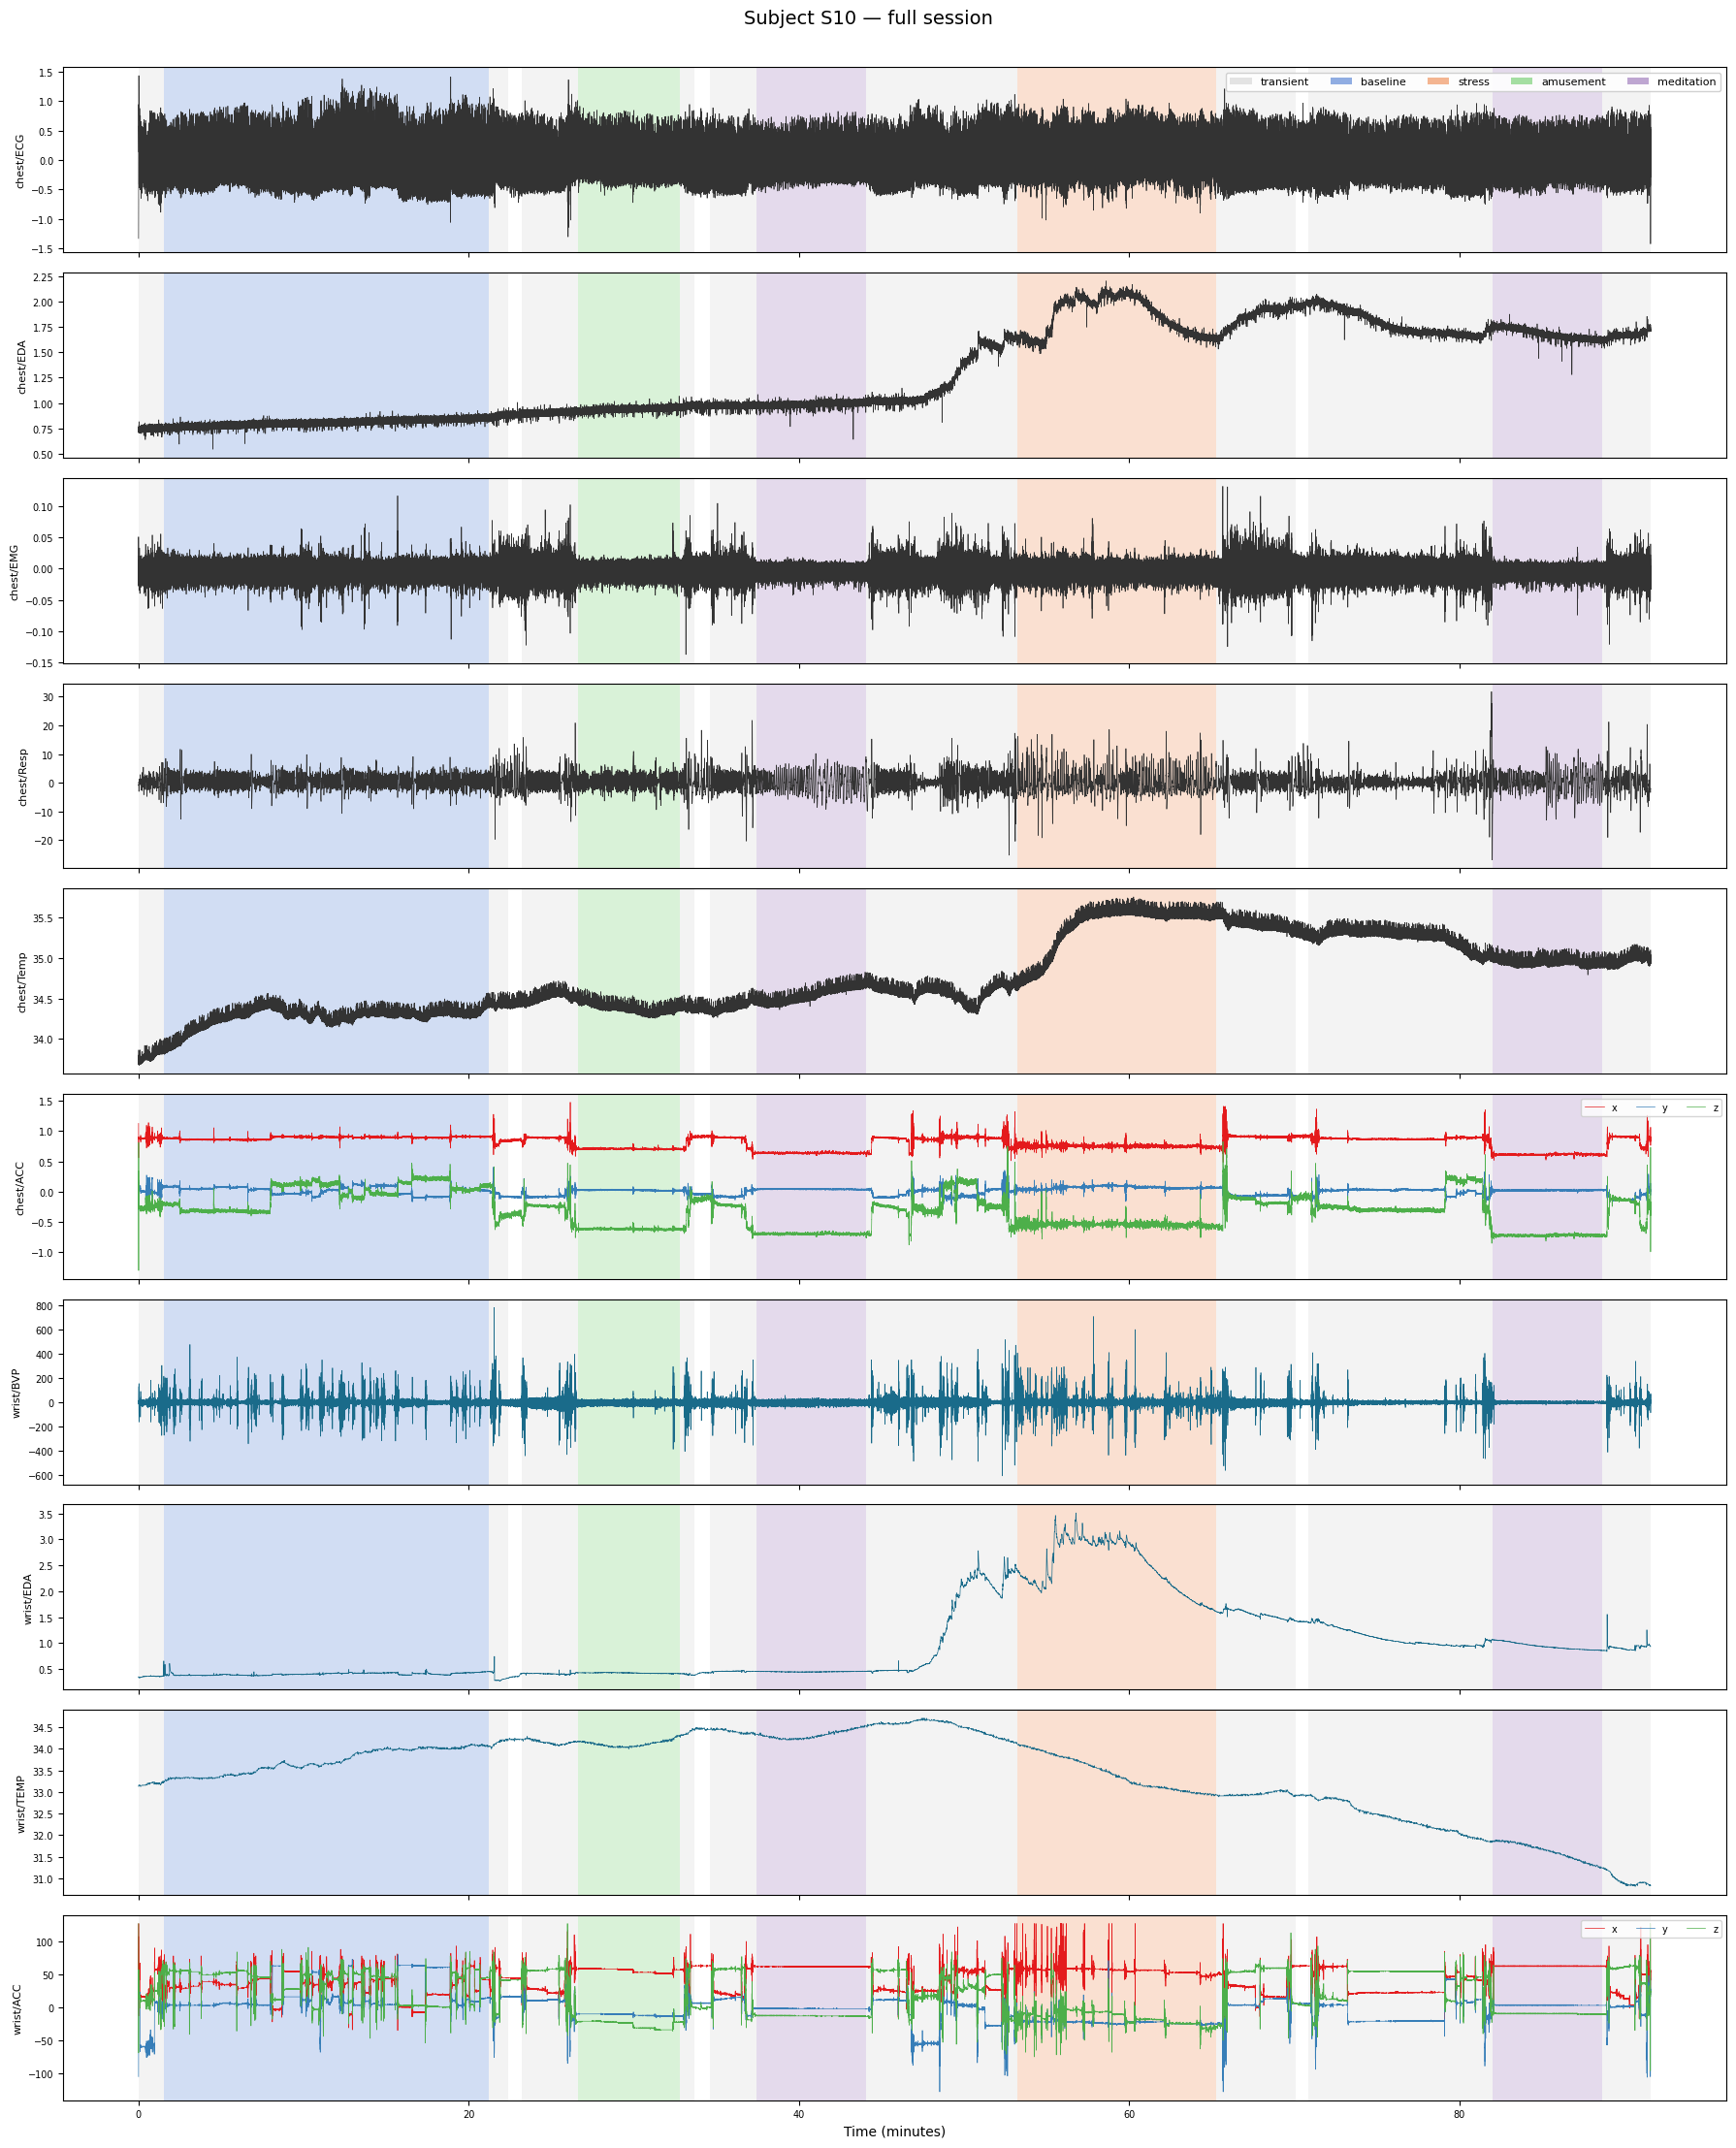

In [6]:
plot_subject(10)   # change sid to any subject in SUBJECT_IDS

### Per-condition signal distributions

Violin + box plots of each signal's distribution across the four conditions. Signals are **z-scored per subject** before pooling so that cross-subject differences in absolute physiological baseline don't wash out the condition effect — what we're visualising is "how many SDs above/below that subject's own mean is each condition?"

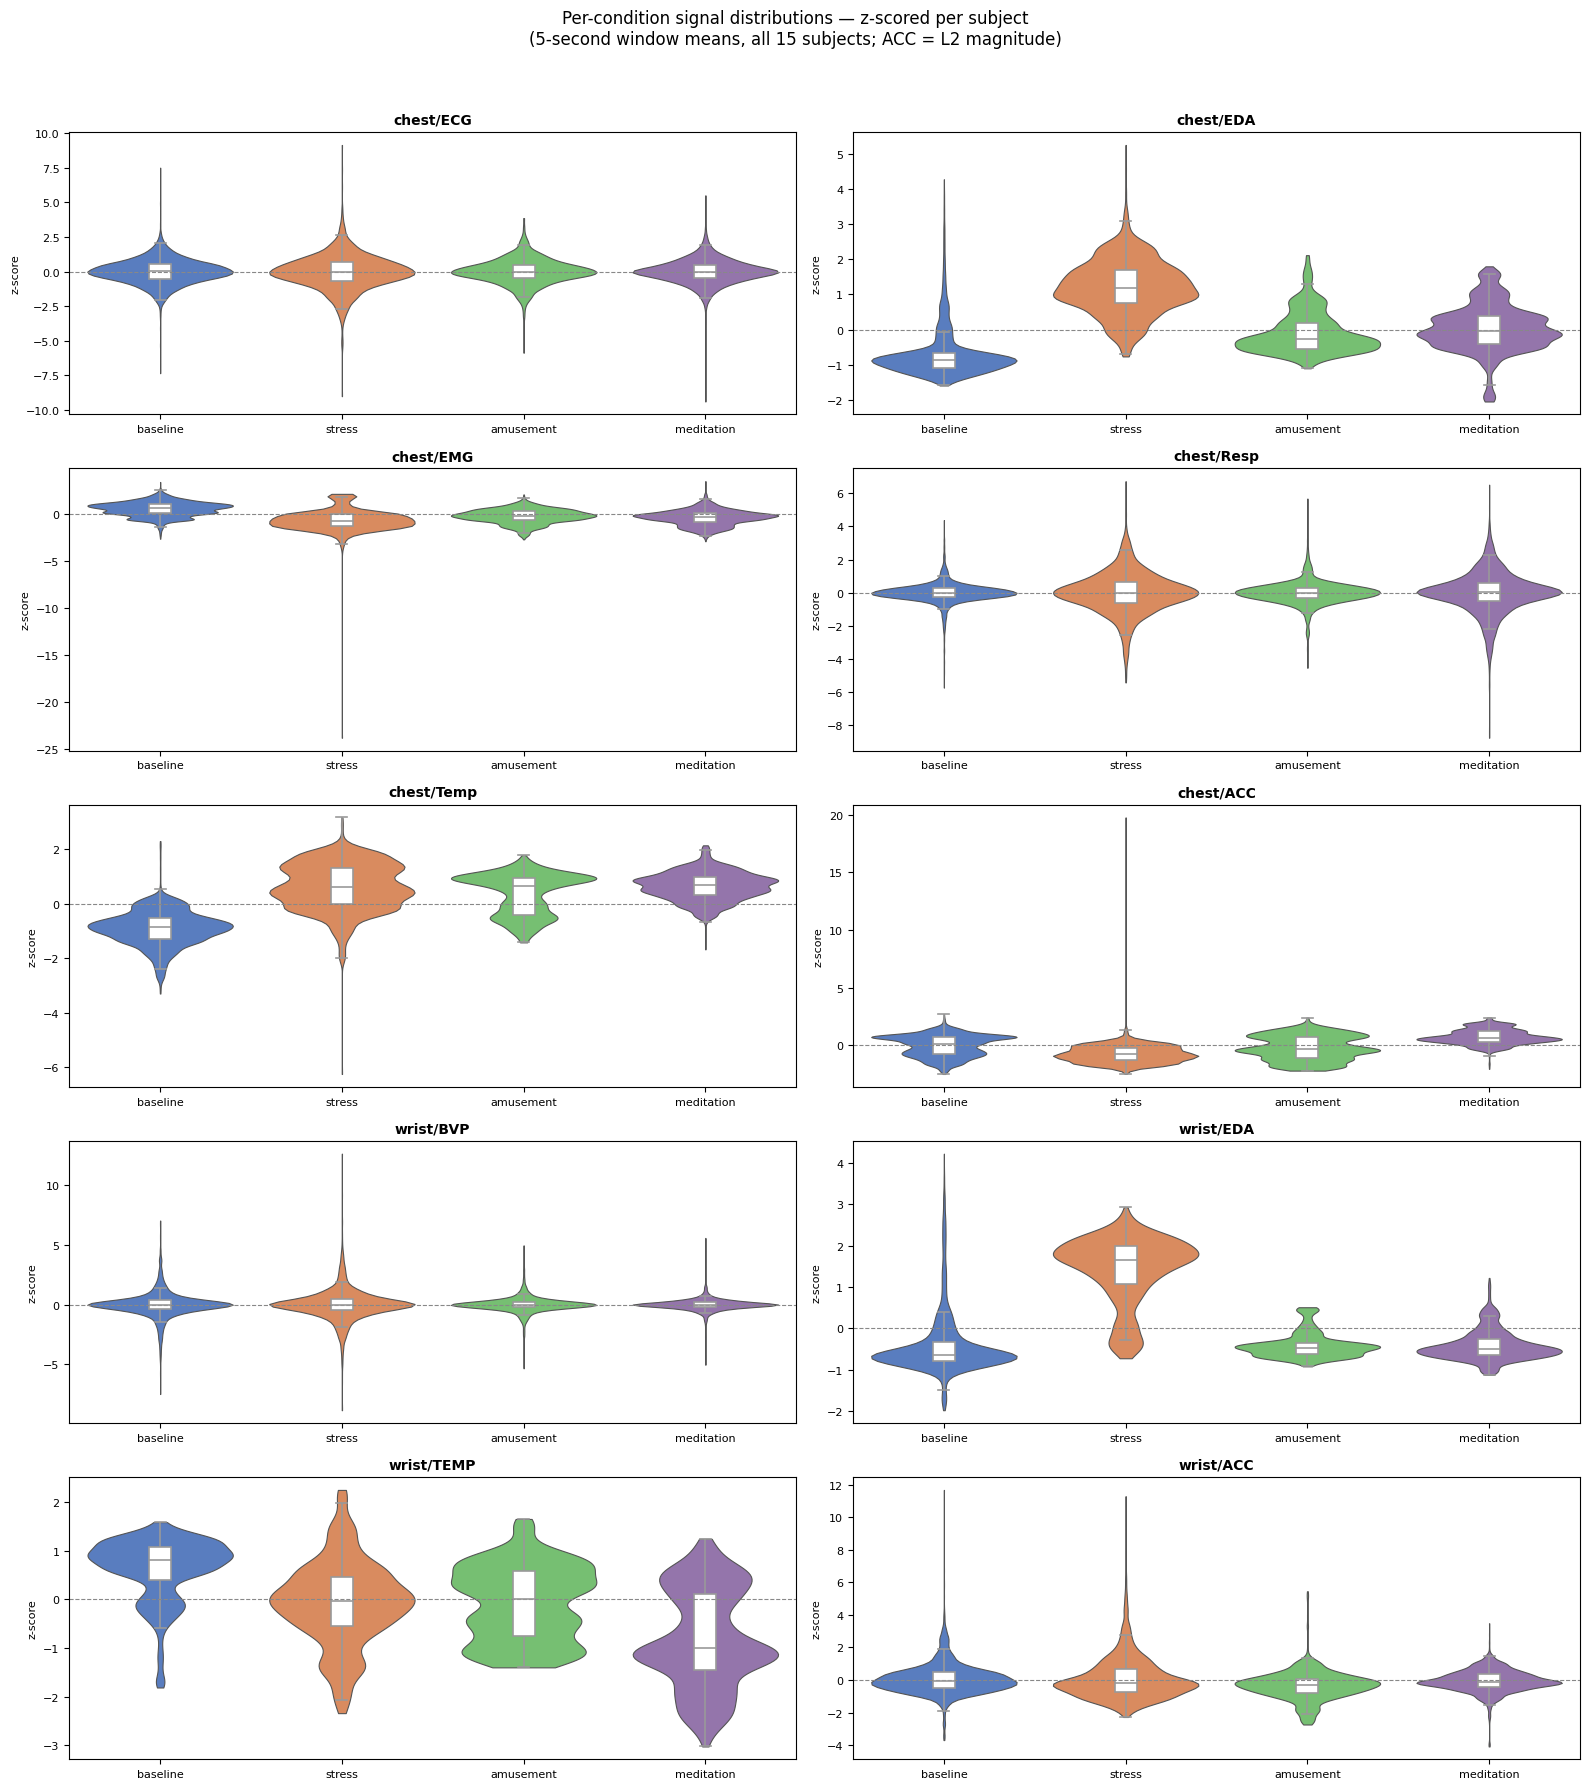

In [7]:
COND_ORDER   = ["baseline", "stress", "amusement", "meditation"]
COND_PALETTE = {
    "baseline":   "#4878d0",
    "stress":     "#ee854a",
    "amusement":  "#6acc65",
    "meditation": "#956cb4",
}


def collect_window_stats(dataset, window_sec=5, conditions=(1, 2, 3, 4)):
    """
    Slice each signal into non-overlapping windows of `window_sec` seconds,
    discard transient / ignored labels, and record the window mean.
    For 3-axis ACC signals, uses the L2 magnitude.

    Returns a DataFrame with columns: signal, condition, value, subject.
    """
    records = []
    for sid, s in dataset.items():
        labels = s["labels"]   # 700 Hz

        # Chest signals ───────────────────────────────────────────────
        for name in ["ECG", "EDA", "EMG", "Resp", "Temp", "ACC"]:
            arr = s["chest"][name]
            if arr.ndim == 2:                            # ACC → magnitude
                arr = np.linalg.norm(arr, axis=1).astype(np.float32)
            win = int(window_sec * FS_CHEST)
            for i in range(len(arr) // win):
                sl   = slice(i * win, (i + 1) * win)
                cond = int(np.median(labels[sl]))
                if cond not in conditions:
                    continue
                records.append({"signal": f"chest/{name}",
                                 "condition": LABEL_NAMES[cond],
                                 "value": float(arr[sl].mean()),
                                 "subject": sid})

        # Wrist signals ───────────────────────────────────────────────
        for name, fs in [("BVP", FS_BVP), ("EDA", FS_EDA_W),
                          ("TEMP", FS_TEMP_W), ("ACC", FS_ACC_W)]:
            arr = s["wrist"][name]
            if arr.ndim == 2:
                arr = np.linalg.norm(arr, axis=1).astype(np.float32)
            n_w  = len(arr)
            # map each wrist sample back to its 700-Hz label
            cidx    = np.clip((np.arange(n_w) / fs * FS_CHEST).astype(int),
                              0, len(labels) - 1)
            wlabels = labels[cidx]
            win     = max(1, int(window_sec * fs))
            for i in range(len(arr) // win):
                sl   = slice(i * win, (i + 1) * win)
                cond = int(np.median(wlabels[sl]))
                if cond not in conditions:
                    continue
                records.append({"signal": f"wrist/{name}",
                                 "condition": LABEL_NAMES[cond],
                                 "value": float(arr[sl].mean()),
                                 "subject": sid})

    return pd.DataFrame(records)


df_wins = collect_window_stats(dataset)

# Z-score per (subject, signal) ───────────────────────────────────────
df_wins["z"] = (df_wins
                .groupby(["subject", "signal"])["value"]
                .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8)))

SIGNALS_ORDER = [
    "chest/ECG", "chest/EDA", "chest/EMG", "chest/Resp", "chest/Temp", "chest/ACC",
    "wrist/BVP", "wrist/EDA", "wrist/TEMP", "wrist/ACC",
]

n_cols = 2
n_rows = len(SIGNALS_ORDER) // n_cols   # 10 signals → 5 rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes_flat = axes.flatten()

for ax, sig in zip(axes_flat, SIGNALS_ORDER):
    sub = df_wins[df_wins["signal"] == sig]
    sns.violinplot(data=sub, x="condition", y="z", order=COND_ORDER,
                   palette=COND_PALETTE, inner=None, linewidth=0.8,
                   cut=0, ax=ax)
    sns.boxplot(data=sub, x="condition", y="z", order=COND_ORDER,
                width=0.12, color="white", linewidth=1.2,
                showfliers=False, ax=ax)
    ax.axhline(0, color="#888", lw=0.8, ls="--")
    ax.set_title(sig, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("z-score", fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(len(SIGNALS_ORDER), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    "Per-condition signal distributions — z-scored per subject\n"
    "(5-second window means, all 15 subjects; ACC = L2 magnitude)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()